In [31]:
import datetime
import hvplot.xarray  # noqa

import pygadm
from xarray import set_options
from conflict_monitoring_ntl.utils import binarize_xarray
from conflict_monitoring_ntl.satellites import BlackMarblePy, GHSLUrbanization
from rasterio.enums import Resampling
import geopandas as gpd

from conflict_monitoring_ntl.transform import RasterPipeline

_ = set_options(use_new_combine_kwarg_defaults=True)

In [38]:
rasters = [BlackMarblePy(frequency="monthly"), GHSLUrbanization()]
date = datetime.date(2020, 1, 1)
gdf = pygadm.Items(name="Vaud", content_level=1)
gdf = gpd.GeoDataFrame(gdf.iloc[[0]].geometry).set_crs("EPSG:4326")

transformations = [
    {"reproject_match": {"resampling": Resampling.average}}, 
    {}
]
pipeline = RasterPipeline(gdf, date, rasters, transformations)
ds = pipeline.run()
ds["black_marble_binary"] = binarize_xarray(ds.black_marble_radiance_monthly, 2)

OBTAINING MANIFEST...:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-10 11:34:56,137 - httpx - INFO - HTTP Request: GET https://ladsweb.modaps.eosdis.nasa.gov/api/v1/files?product=VNP46A3&collection=5200&dateRanges=2020-01-01..2020-01-01&areaOfInterest=x6.06y46.19%2Cx7.25y46.99 "HTTP/1.1 200 OK"


QUEUEING TASKS | Downloading (99.0 MB)...:   0%|          | 0/1 [00:00<?, ?file/s]

PROCESSING TASKS | Downloading (99.0 MB)...:   0%|          | 0/1 [00:00<?, ?file/s]

COLLECTING RESULTS | Downloading (99.0 MB)...:   0%|          | 0/1 [00:00<?, ?file/s]

COLLATING TILES | Processing...:   0%|          | 0/1 [00:00<?, ?date/s]

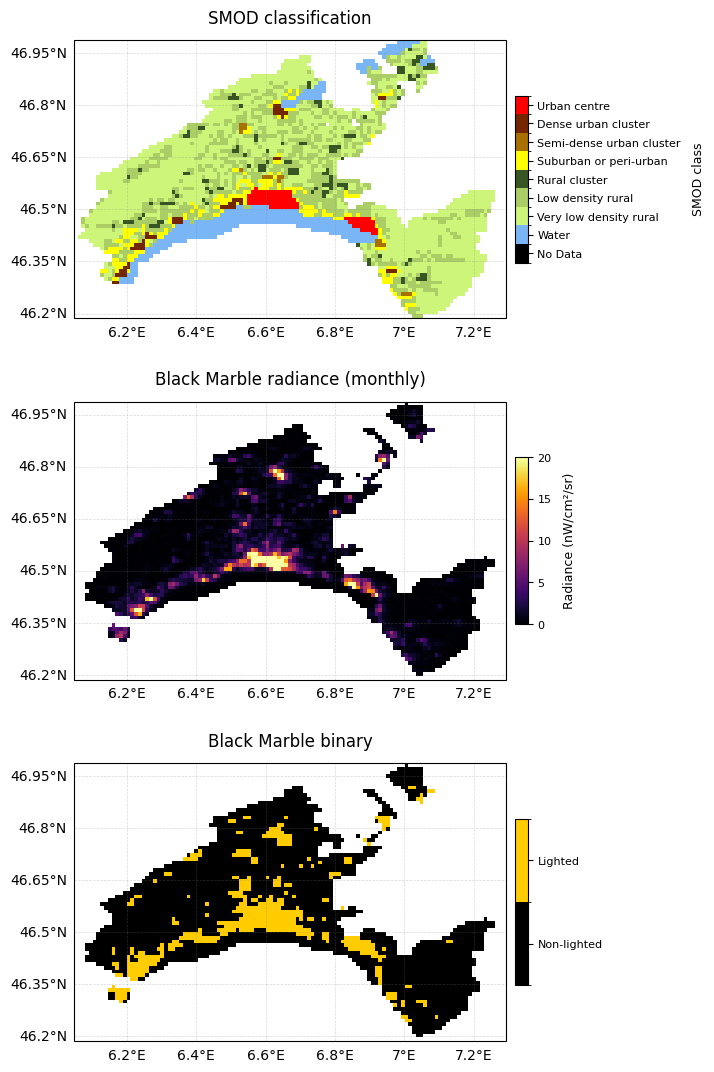

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FixedLocator, FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- 1. SMOD DISCRETE SETUP (TOP PANEL) ---
codes  = np.array([-200, 10, 11, 12, 13, 21, 22, 23, 30])
colors = [
    "#000000",
    "#7ab6f5",
    "#cdf57a",
    "#abcd66",
    "#375623",
    "#ffff00",
    "#a87000",
    "#732600",
    "#ff0000",
]
labels = [
    "No Data",
    "Water",
    "Very low density rural",
    "Low density rural",
    "Rural cluster",
    "Suburban or peri-urban",
    "Semi-dense urban cluster",
    "Dense urban cluster",
    "Urban centre",
]

cmap_smod = ListedColormap(colors)

bounds = np.concatenate([
    [codes[0] - 0.5],
    0.5 * (codes[:-1] + codes[1:]),
    [codes[-1] + 0.5],
])
norm_smod = BoundaryNorm(bounds, cmap_smod.N)
tick_locs = 0.5 * (bounds[:-1] + bounds[1:])

def smod_tick_formatter(x, pos):
    idx = np.argmin(np.abs(tick_locs - x))
    return labels[idx]

# --- 2. DATA ---
da_smod = ds.smod_code
da_bm   = ds.black_marble_radiance_monthly
da_bin  = ds.black_marble_binary  # 0/1, same lon/lat grid

# --- 3. FIGURE WITH THREE ROWS ---
fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 13),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# --- 4. TOP: SMOD CLASSIFICATION ---
im_smod = ax_top.pcolormesh(
    da_smod["lon"],
    da_smod["lat"],
    da_smod,
    cmap=cmap_smod,
    norm=norm_smod,
    transform=ccrs.PlateCarree(),
)

ax_top.coastlines(resolution="10m", color="white", linewidth=0.6, alpha=0.8)
ax_top.set_title("SMOD classification", fontsize=12, pad=12)

gl_top = ax_top.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.3,
    linestyle="--",
)
gl_top.top_labels = False
gl_top.right_labels = False

# compact colorbar outside (right) for SMOD
cax_top = inset_axes(
    ax_top,
    width="3%",
    height="60%",
    loc="center left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax_top.transAxes,
    borderpad=0.0,
)
cbar_top = fig.colorbar(im_smod, cax=cax_top, orientation="vertical")
cbar_top.locator = FixedLocator(tick_locs)
cbar_top.formatter = FuncFormatter(smod_tick_formatter)
cbar_top.update_ticks()
cbar_top.ax.tick_params(labelsize=8)
cbar_top.set_label("SMOD class", fontsize=9, labelpad=8)

# --- 5. MIDDLE: BLACK MARBLE RADIANCE ---
im_bm = ax_mid.pcolormesh(
    da_bm["lon"],
    da_bm["lat"],
    da_bm,
    cmap="inferno",
    vmin=0,
    vmax=20,
    transform=ccrs.PlateCarree(),
)

ax_mid.coastlines(resolution="10m", color="white", linewidth=0.6, alpha=0.8)
ax_mid.set_title("Black Marble radiance (monthly)", fontsize=12, pad=12)

gl_mid = ax_mid.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.3,
    linestyle="--",
)
gl_mid.top_labels = False
gl_mid.right_labels = False

cax_mid = inset_axes(
    ax_mid,
    width="3%",
    height="60%",
    loc="center left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax_mid.transAxes,
    borderpad=0.0,
)
cbar_mid = fig.colorbar(im_bm, cax=cax_mid, orientation="vertical")
cbar_mid.ax.tick_params(labelsize=8)
cbar_mid.set_label("Radiance (nW/cm²/sr)", fontsize=9, labelpad=8)

# --- 6. BOTTOM: BLACK MARBLE BINARY (0/1, classification) ---

# define binary classes and labels
bin_codes  = np.array([0, 1])
bin_colors = ["#000000", "#ffcc00"]  # e.g. black = non-lighted, yellow = lighted
bin_labels = ["Non-lighted", "Lighted"]

cmap_bin = ListedColormap(bin_colors)

# boundaries around 0 and 1
bin_bounds = np.array([-0.5, 0.5, 1.5])
norm_bin = BoundaryNorm(bin_bounds, cmap_bin.N)

# tick locations at bin centers
bin_tick_locs = np.array([0, 1])

def bin_tick_formatter(x, pos):
    idx = int(round(x))
    if idx in (0, 1):
        return bin_labels[idx]
    return ""

im_bin = ax_bottom.pcolormesh(
    da_bin["lon"],
    da_bin["lat"],
    da_bin,
    cmap=cmap_bin,
    norm=norm_bin,
    transform=ccrs.PlateCarree(),
)

ax_bottom.coastlines(resolution="10m", color="white", linewidth=0.6, alpha=0.8)
ax_bottom.set_title("Black Marble binary", fontsize=12, pad=12)

gl_bot = ax_bottom.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.3,
    linestyle="--",
)
gl_bot.top_labels = False
gl_bot.right_labels = False

cax_bot = inset_axes(
    ax_bottom,
    width="3%",
    height="60%",
    loc="center left",
    bbox_to_anchor=(1.02, 0, 1, 1),
    bbox_transform=ax_bottom.transAxes,
    borderpad=0.0,
)
cbar_bot = fig.colorbar(im_bin, cax=cax_bot, orientation="vertical")

cbar_bot.locator = FixedLocator(bin_tick_locs)
cbar_bot.formatter = FuncFormatter(bin_tick_formatter)
cbar_bot.update_ticks()

cbar_bot.ax.tick_params(labelsize=8)

fig.subplots_adjust(hspace=0.3) 
plt.show()
